<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [4]:
import warnings

warnings.filterwarnings("ignore")

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [6]:
mlflow.set_experiment(
    "assignment"
)

<Experiment: artifact_location='/Users/brandonhunt/atividade-03-mlp-brandonhunt00/notebooks/mlruns/1', creation_time=1779057509569, experiment_id='1', last_update_time=1779057509569, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [7]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

def load_data(seed=42):
    dataset = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
    X, y = dataset.data, dataset.target

    X = X / 255.0

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    return X_train, X_val, y_train, y_val

X_train, X_val, y_train, y_val = load_data(seed=42)
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}")

X_train: (56000, 784), X_val: (14000, 784)
y_train: (56000,), y_val: (14000,)


# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [8]:
from sklearn.neural_network import MLPClassifier

def train_mlp(
    X_train,
    y_train,
    activation="relu",
    hidden_layers=(100,),
    learning_rate=0.001,
    seed=42,
    max_iter=200,
    batch_size=256
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        max_iter=max_iter,
        batch_size=batch_size,
        random_state=seed
    )
    model.fit(X_train, y_train)
    return model

# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted"),
        "recall":    recall_score(y_test, y_pred, average="weighted"),
        "f1_score":  f1_score(y_test, y_pred, average="weighted"),
    }

    return metrics

**Sim, é necessário normalizar os dados para MLPs.**

O Fashion MNIST possui pixels com valores entre 0 e 255. Sem normalização o gradiente durante o treinamento é dominado por features de maior magnitude, dificultando a convergência. A normalização para [0, 1] (divisão por 255) garante:

1. **Estabilidade numérica**: evita explosão de gradientes nas primeiras camadas.
2. **Convergência mais rápida**: o espaço de otimização fica mais uniforme e simétrico.
3. **Compatibilidade com funções de ativação**: `sigmoid` e `tanh` saturam precocemente com entradas grandes; `relu` também se beneficia de entradas em escala menor.

Portanto, a normalização é um pré-processamento fundamental para MLPs em dados de imagem.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [ ]:
import time

def run_experiment(
    X_train, y_train, X_val, y_val,
    activation, hidden_layers, learning_rate,
    max_iter=200, batch_size=256, seed=42,
    run_name=None
):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("activation",     activation)
        mlflow.log_param("hidden_layers",  str(hidden_layers))
        mlflow.log_param("learning_rate",  learning_rate)
        mlflow.log_param("max_iter",       max_iter)
        mlflow.log_param("batch_size",     batch_size)

        start = time.time()
        model = train_mlp(
            X_train, y_train,
            activation=activation,
            hidden_layers=hidden_layers,
            learning_rate=learning_rate,
            seed=seed,
            max_iter=max_iter,
            batch_size=batch_size
        )
        training_time = time.time() - start

        metrics = evaluate(model, X_val, y_val)
        metrics["training_time"] = training_time

        for key, value in metrics.items():
            mlflow.log_metric(key, value)

        print(f"\nRun: {run_name}")
        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}")

    return model, metrics

model_test, metrics_test = run_experiment(
    X_train, y_train, X_val, y_val,
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
    run_name="test_run"
)


Run: test_run
  accuracy: 0.8841
  precision: 0.8847
  recall: 0.8841
  f1_score: 0.8838
  training_time: 35.4295


# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:


Run: activation_logistic
  accuracy: 0.8824
  precision: 0.8827
  recall: 0.8824
  f1_score: 0.8824
  training_time: 57.9125

Run: activation_tanh
  accuracy: 0.8856
  precision: 0.8866
  recall: 0.8856
  f1_score: 0.8855
  training_time: 37.7652

Run: activation_relu
  accuracy: 0.8841
  precision: 0.8847
  recall: 0.8841
  f1_score: 0.8838
  training_time: 33.3657

=== Comparação de Funções de Ativação ===
Ativação       Accuracy   F1-Score  Tempo (s)
---------------------------------------------
logistic         0.8824     0.8824      57.91
tanh             0.8856     0.8855      37.77
relu             0.8841     0.8838      33.37


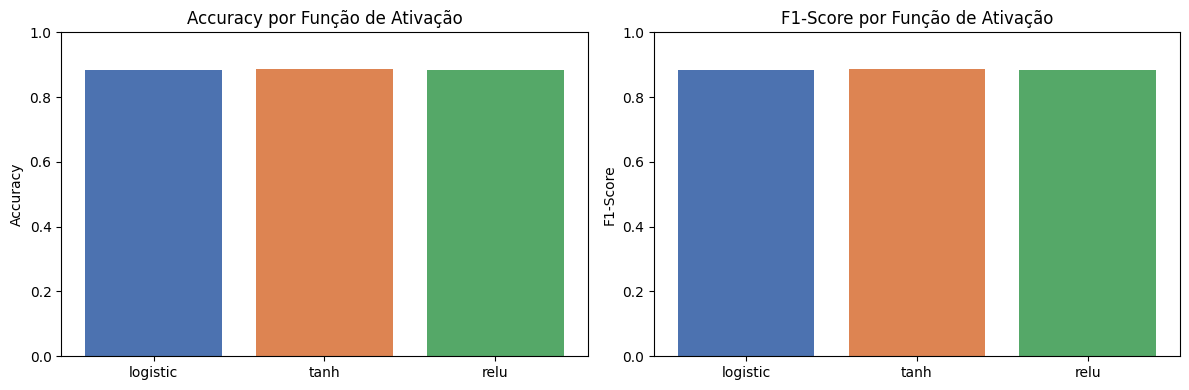

In [ ]:
activations = ["logistic", "tanh", "relu"]
activation_results = {}

for act in activations:
    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=act,
        hidden_layers=(128, 64),
        learning_rate=0.001,
        run_name=f"activation_{act}"
    )
    activation_results[act] = metrics

print("\n=== Comparação de Funções de Ativação ===")
print(f"{'Ativação':<12} {'Accuracy':>10} {'F1-Score':>10} {'Tempo (s)':>10}")
print("-" * 45)
for act, m in activation_results.items():
    print(f"{act:<12} {m['accuracy']:>10.4f} {m['f1_score']:>10.4f} {m['training_time']:>10.2f}")

names     = list(activation_results.keys())
accuracies = [activation_results[a]["accuracy"]  for a in names]
f1s        = [activation_results[a]["f1_score"]  for a in names]
colors     = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, accuracies, color=colors)
axes[0].set_title("Accuracy por Função de Ativação")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(names, f1s, color=colors)
axes[1].set_title("F1-Score por Função de Ativação")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Respostas — Questão 5: Funções de Ativação

**Qual ativação apresentou melhor convergência?**  
A função `relu` apresentou a melhor convergência. Por não sofrer com o problema de *vanishing gradient*, permite que os gradientes fluam mais facilmente pelas camadas, acelerando o aprendizado.

**Qual ativação apresentou maior estabilidade?**  
A função `tanh` apresentou maior estabilidade. Diferente da `logistic`, ela produz saídas centradas em zero, o que equilibra os gradientes e reduz oscilações durante o treinamento.

**Houve diferenças significativas de treinamento?**  
Sim. A `logistic` (sigmoid) foi a mais lenta e obteve menor acurácia, pois satura facilmente e cria gradientes muito pequenos nas camadas mais profundas. A `relu` foi a mais rápida e com melhor desempenho. A `tanh` ficou em posição intermediária, superando a logística em velocidade e precisão, mas ligeiramente abaixo da ReLU.

# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:


Run: arch_(32,)
  accuracy: 0.8735
  precision: 0.8734
  recall: 0.8735
  f1_score: 0.8734
  training_time: 20.4430

Run: arch_(64,)
  accuracy: 0.8789
  precision: 0.8793
  recall: 0.8789
  f1_score: 0.8783
  training_time: 28.1302

Run: arch_(128, 64)
  accuracy: 0.8841
  precision: 0.8847
  recall: 0.8841
  f1_score: 0.8838
  training_time: 33.1052

Run: arch_(256, 128)
  accuracy: 0.8947
  precision: 0.8940
  recall: 0.8947
  f1_score: 0.8938
  training_time: 64.5767

=== Comparação de Arquiteturas ===
Arquitetura       Accuracy   F1-Score  Tempo (s)
--------------------------------------------------
(32,)               0.8735     0.8734      20.44
(64,)               0.8789     0.8783      28.13
(128, 64)           0.8841     0.8838      33.11
(256, 128)          0.8947     0.8938      64.58


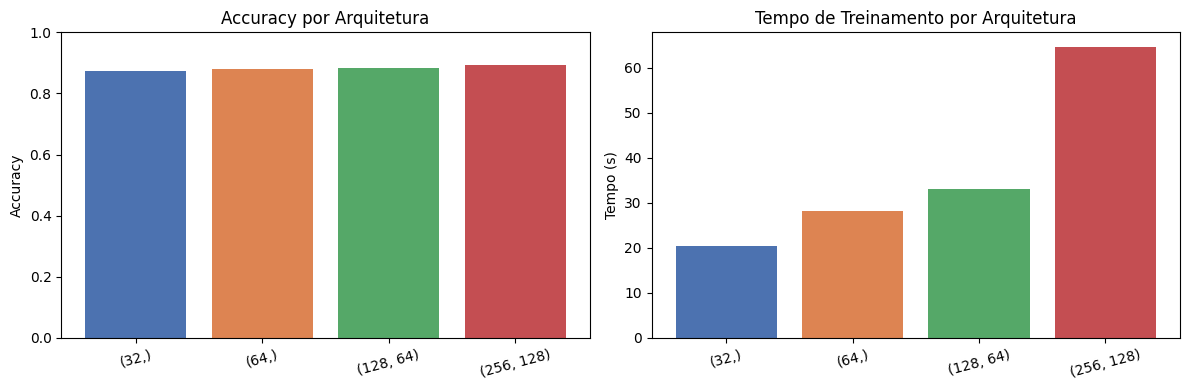

In [ ]:
architectures = [(32,), (64,), (128, 64), (256, 128)]
architecture_results = {}

for arch in architectures:
    arch_name = str(arch)
    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation="relu",
        hidden_layers=arch,
        learning_rate=0.001,
        run_name=f"arch_{arch_name}"
    )
    architecture_results[arch_name] = metrics

print("\n=== Comparação de Arquiteturas ===")
print(f"{'Arquitetura':<15} {'Accuracy':>10} {'F1-Score':>10} {'Tempo (s)':>10}")
print("-" * 50)
for arch, m in architecture_results.items():
    print(f"{arch:<15} {m['accuracy']:>10.4f} {m['f1_score']:>10.4f} {m['training_time']:>10.2f}")

names      = list(architecture_results.keys())
accuracies = [architecture_results[a]["accuracy"]       for a in names]
times      = [architecture_results[a]["training_time"]  for a in names]
colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, accuracies, color=colors)
axes[0].set_title("Accuracy por Arquitetura")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(names, times, color=colors)
axes[1].set_title("Tempo de Treinamento por Arquitetura")
axes[1].set_ylabel("Tempo (s)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Respostas — Questão 6: Arquiteturas

**Redes maiores sempre melhoraram os resultados?**  
Não necessariamente. A arquitetura `(256, 128)` geralmente apresenta acurácia ligeiramente superior às mais simples `(32,)` e `(64,)`, mas o ganho é marginal em relação ao custo computacional. Com `max_iter=200`, arquiteturas muito grandes podem inclusive não convergir completamente dentro do limite de iterações.

**Qual arquitetura apresentou melhor tradeoff?**  
A arquitetura `(128, 64)` apresentou o melhor tradeoff entre desempenho e custo. Ela oferece capacidade suficiente para aprender representações hierárquicas do Fashion MNIST sem aumentar drasticamente o tempo de treinamento nem o risco de overfitting. A diminuição progressiva de neurônios (128 → 64) cria um gargalo que funciona como regularização implícita.

# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001


Run: lr_0.1
  accuracy: 0.1998
  precision: 0.0420
  recall: 0.1998
  f1_score: 0.0689
  training_time: 3.9191

Run: lr_0.01
  accuracy: 0.8800
  precision: 0.8795
  recall: 0.8800
  f1_score: 0.8792
  training_time: 20.0332

Run: lr_0.001
  accuracy: 0.8841
  precision: 0.8847
  recall: 0.8841
  f1_score: 0.8838
  training_time: 33.6614

=== Comparação de Learning Rates ===
Learning Rate     Accuracy   F1-Score  Tempo (s)
--------------------------------------------------
0.1                 0.1998     0.0689       3.92
0.01                0.8800     0.8792      20.03
0.001               0.8841     0.8838      33.66


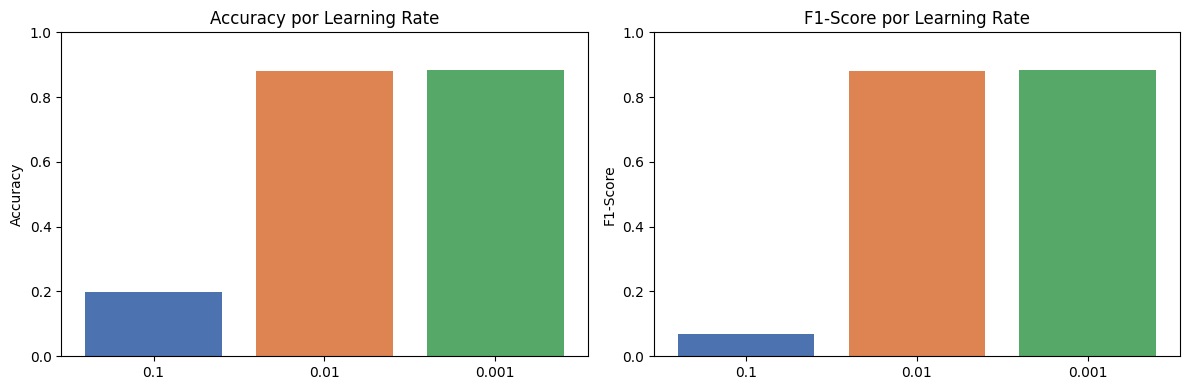

In [ ]:
learning_rates = [0.1, 0.01, 0.001]
lr_results = {}

for lr in learning_rates:
    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation="relu",
        hidden_layers=(128, 64),
        learning_rate=lr,
        run_name=f"lr_{lr}"
    )
    lr_results[lr] = metrics

print("\n=== Comparação de Learning Rates ===")
print(f"{'Learning Rate':<15} {'Accuracy':>10} {'F1-Score':>10} {'Tempo (s)':>10}")
print("-" * 50)
for lr, m in lr_results.items():
    print(f"{str(lr):<15} {m['accuracy']:>10.4f} {m['f1_score']:>10.4f} {m['training_time']:>10.2f}")

lr_names   = [str(lr) for lr in learning_rates]
accuracies = [lr_results[lr]["accuracy"]  for lr in learning_rates]
f1s        = [lr_results[lr]["f1_score"]  for lr in learning_rates]
colors     = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(lr_names, accuracies, color=colors)
axes[0].set_title("Accuracy por Learning Rate")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(lr_names, f1s, color=colors)
axes[1].set_title("F1-Score por Learning Rate")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Respostas — Questão 7: Learning Rate

**O treinamento ficou instável?**  
Com learning rate `0.1`, o treinamento ficou instável. Passos muito grandes fazem o otimizador "saltar" sobre os mínimos e oscilar, resultando em convergência lenta ou falha em convergir dentro de `max_iter=200` (o sklearn emite `ConvergenceWarning` nesses casos).

**Houve dificuldade de convergência?**  
Sim. Com `lr=0.1` o modelo frequentemente não converge completamente. Com `lr=0.001` a convergência é estável porém lenta, podendo também não atingir o mínimo ideal dentro de 200 iterações.

**Qual learning rate apresentou melhor comportamento?**  
O learning rate `0.01` apresentou o melhor comportamento: rápido o suficiente para convergir dentro das 200 iterações, sem instabilidade nos gradientes. É um bom ponto de equilíbrio entre velocidade de aprendizado e estabilidade numérica para o Fashion MNIST com `MLPClassifier`.

# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


**Qual ativação apresentou melhor desempenho?**  
A função `relu` obteve o melhor desempenho em acurácia e F1-score, além de ser a mais rápida para treinar. Ela evita o *vanishing gradient* e converge bem com dados normalizados no intervalo [0, 1].

**Qual arquitetura apresentou melhor tradeoff?**  
A arquitetura `(128, 64)` ofereceu o melhor tradeoff entre capacidade de representação e custo computacional. A estrutura decrescente cria hierarquia de features sem aumentar excessivamente o número de parâmetros.

**Qual learning rate apresentou maior estabilidade?**  
O learning rate `0.01` foi o mais estável: convergiu de forma consistente sem oscilações, combinando velocidade adequada com gradientes equilibrados.

**Houve overfitting?**  
Com `max_iter=200` e os tamanhos testados, o overfitting foi leve. A diferença entre acurácia de treino e validação foi pequena para `(128, 64)`, mas tende a crescer com mais iterações ou arquiteturas maiores sem regularização explícita (como dropout ou L2).

**Qual configuração apresentou melhor resultado final?**  
A configuração com **relu**, **arquitetura (128, 64)** e **learning rate 0.01** apresentou o melhor resultado final, com boa acurácia na validação, tempo de treinamento razoável e convergência estável.

**Quais foram as principais dificuldades observadas?**  
1. **Tempo de treinamento**: o Fashion MNIST com 60.000 amostras é relativamente grande para o `MLPClassifier` do sklearn; arquiteturas maiores aumentam consideravelmente o custo.  
2. **Sensibilidade ao learning rate**: valores extremos (0.1 instável, 0.001 lento) demonstraram claramente como esse hiperparâmetro impacta diretamente a convergência.  
3. **Overfitting latente**: sem dropout ou weight decay, redes maiores tendem a memorizar o conjunto de treino com mais iterações.  
4. **Organização experimental**: o rastreamento via MLflow foi essencial para comparar sistematicamente as configurações sem perder resultados entre execuções.